## Data Preparation and Initial Data Analysis(IDA)

This notebook prepares and explores the raw Guardian dataset.\
The focus is on data cleaning, basic data quality checks, and creating variables for further analysis.

## 1. Load the raw dataset

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv("data/raw/combined_raw.csv")

print("Shape:", df.shape)
print("Columns:", df.columns)

df.head()

Shape: (25142, 7)
Columns: Index(['university', 'id', 'webPublicationDate', 'sectionId', 'sectionName',
       'webTitle', 'wordcount'],
      dtype='object')


,university,id,webPublicationDate,sectionId,sectionName,webTitle,wordcount
0,University of Birmingham,theguardian/2010/jan/03/simonedebeauvoir-oxfor...,2010-01-03T18:36:43Z,global,Global,Elizabeth Fallaize obituary,1007
1,University of Birmingham,education/2010/jan/19/gel-curb-appetite-scient...,2010-01-19T00:05:05Z,education,Education,Food scientists develop appetite-curbing gel,839
2,University of Birmingham,science/2010/jan/25/mary-english-obituary,2010-01-25T18:38:39Z,science,Science,Mary English obituary,931
3,University of Birmingham,science/video/2010/feb/03/good-guys-draw-faste...,2010-02-03T04:50:00Z,science,Science,Video: Why the good guys draw faster in a gunf...,0
4,University of Birmingham,education/2010/feb/06/cv-clinic-jenny-adams,2010-02-06T00:05:03Z,education,Education,CV Clinic,552


### Explanation

The dataset is loaded to inspect its structure, including the number of rows, columns, and variable names.\
This helps us understand what variables are available before cleaning.

## 2. Basic data quality checks

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25142 entries, 0 to 25141
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   university          25142 non-null  object
 1   id                  25142 non-null  object
 2   webPublicationDate  25142 non-null  object
 3   sectionId           25142 non-null  object
 4   sectionName         25142 non-null  object
 5   webTitle            25142 non-null  object
 6   wordcount           25142 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 1.3+ MB


In [11]:
df.isna().sum()

university            0
id                    0
webPublicationDate    0
sectionId             0
sectionName           0
webTitle              0
wordcount             0
dtype: int64

In [12]:
#check for full-row duplicates
print("Full-row duplicates:", df.duplicated().sum())

Full-row duplicates: 0


In [24]:
#check for cross-university article overlap
#the same Guardian article can mention multiple universities,
#so it may appear under more than one university search
print(f"Total rows: {len(df)}")
print(f"Unique article IDs: {df['id'].nunique()}")

#find articles that appear more than once
dup_mask = df['id'].duplicated(keep=False)
dup_articles = df[dup_mask]
print(f"Rows with shared article IDs: {len(dup_articles)}")

#how many universities does each shared article appear under?
unis_per_article = dup_articles.groupby('id')['university'].nunique()
print(f"\nShared across 2 universities: {(unis_per_article == 2).sum()}")
print(f"Shared across 3+ universities: {(unis_per_article >= 3).sum()}")

#show an example
sample_id = dup_articles['id'].iloc[0]
print(f"\nExample - article ID: {sample_id}")
df[df['id'] == sample_id][['university', 'webTitle']]

Total rows: 25142
Unique article IDs: 22021
Rows with shared article IDs: 5411

Shared across 2 universities: 1800
Shared across 3+ universities: 490

Example - article ID: service-design/polymorphs


,university,webTitle
8,University of Birmingham,Polymorphs in the making
19965,University College London,Polymorphs in the making


### Cross-university article overlap

There are no full-row duplicates, but 5,411 rows (21.5% of the dataset) share an article ID with at least one other row. This is not an error - it occurs because a single Guardian article can mention multiple universities (e.g. an article about Oxford–Cambridge collaboration appears under both searches).

All 2,290 shared articles appear under different universities, never the same one twice, confirming our data collection was clean.

Handling decision: We keep all rows for per-university analysis, since each row represents a mention of that university in the Guardian. However, we note that summing article counts across all universities will overcount the total number of unique articles. Where total counts matter (e.g. overall yearly trends), we will use deduplicated data.

In [14]:
df["wordcount"].describe()

count    25142.000000
mean      1423.447975
std       2471.551938
min          0.000000
25%        599.000000
50%        809.000000
75%       1134.750000
max      42709.000000
Name: wordcount, dtype: float64

In [15]:
#investigate articles with wordcount = 0
zero_wc = df[df['wordcount'] == 0]
print(f"Articles with wordcount = 0: {len(zero_wc)}")
print(f"\nThese are typically video or interactive content:")
zero_wc[['university', 'webTitle', 'sectionName']].head(8)

Articles with wordcount = 0: 60

These are typically video or interactive content:


,university,webTitle,sectionName
3,University of Birmingham,Video: Why the good guys draw faster in a gunf...,Science
67,University of Birmingham,Scientists create invisibility cloak - video,Science
273,University of Birmingham,Gay marriage in Britain: a history - student f...,Education
336,University of Birmingham,Is an arts degree worth the tuition fees? - fi...,Opinion
356,University of Birmingham,Tackling creationism head-on in science lesson...,Science
1455,University of Bristol,Love song of a Jurassic cricket - video,Science
1593,University of Bristol,Danceroom Spectroscopy: dancing molecules brin...,Science
2706,University of Cambridge,'There's a responsibility for people who look ...,Opinion


### Wordcount = 0 articles

60 articles have a wordcount of zero. Inspecting them reveals they are video content (the titles contain "video", "film", etc.). These are legitimate Guardian content but contain no article text. We retain them in the dataset since they still represent media coverage, but they should be excluded from any analysis that uses wordcount as a variable.

### Summary of data quality checks

Initial inspection reveals:
- No missing values across all seven variables.
- No full-row duplicates, but 5,411 rows share an article ID with another row due to cross-university overlap. This is expected and handled as described above.
- 60 articles have wordcount = 0, corresponding to video content.
- The wordcount distribution is right-skewed (median 809, mean 1,423, max 42,709), which is typical for article length data.
- The dataset contains both categorical variables (university, sectionId, sectionName, webTitle) and one numerical variable (wordcount), plus a datetime string (webPublicationDate) that requires conversion.

### Coverage check: articles per university per year


In [17]:
#check that each university has reasonable coverage across all years
df['year'] = pd.to_datetime(df['webPublicationDate']).dt.year
coverage = pd.crosstab(df['university'], df['year'])
coverage

year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
university,,,,,,,,,,,,,,,
Cardiff University,157,143,111,116,88,121,102,103,64,76,86,79,70,49,66
Imperial College London,122,132,152,157,172,126,153,130,144,100,435,425,218,186,145
London School of Economics,292,437,357,293,308,333,322,254,207,186,269,209,170,177,166
University College London,318,366,307,328,380,399,343,297,293,285,539,477,276,321,298
University of Birmingham,61,96,93,106,111,93,87,79,89,78,125,94,71,63,69
University of Bristol,48,87,77,87,85,84,90,68,69,79,136,166,86,94,88
University of Cambridge,67,121,124,169,170,157,178,152,157,160,207,218,151,190,167
University of Edinburgh,69,79,56,82,100,86,106,87,89,78,243,232,136,118,101
University of Manchester,74,100,98,170,139,164,134,152,118,123,124,141,99,104,88


All 10 universities have articles in every year from 2010 to 2024, with no gaps. Coverage is uneven — UCL and LSE consistently have the most articles per year — but no university drops to zero in any period, confirming the dataset supports time-series comparisons across all 15 years.


## 3. Data cleaning

In [21]:
clean_df = df.copy()

# remove duplicates
clean_df = clean_df.drop_duplicates()

# convert date to datetime
clean_df["webPublicationDate"] = pd.to_datetime(clean_df["webPublicationDate"])

# remove bad dates
clean_df = clean_df.dropna(subset=["webPublicationDate"])

# create time variables
clean_df["year"] = clean_df["webPublicationDate"].dt.year
clean_df["month"] = clean_df["webPublicationDate"].dt.month
clean_df["year_month"] = clean_df["year"].astype(str) + "-" + clean_df["month"].astype(str).str.zfill(2)

# clean wordcount
clean_df["wordcount"] = pd.to_numeric(clean_df["wordcount"])
clean_df = clean_df.dropna(subset=["wordcount"])
clean_df = clean_df[clean_df["wordcount"] >= 0]

print(clean_df.shape)
clean_df.head()

(25142, 10)


,university,id,webPublicationDate,sectionId,sectionName,webTitle,wordcount,year,month,year_month
0,University of Birmingham,theguardian/2010/jan/03/simonedebeauvoir-oxfor...,2010-01-03 18:36:43+00:00,global,Global,Elizabeth Fallaize obituary,1007,2010,1,2010-01
1,University of Birmingham,education/2010/jan/19/gel-curb-appetite-scient...,2010-01-19 00:05:05+00:00,education,Education,Food scientists develop appetite-curbing gel,839,2010,1,2010-01
2,University of Birmingham,science/2010/jan/25/mary-english-obituary,2010-01-25 18:38:39+00:00,science,Science,Mary English obituary,931,2010,1,2010-01
3,University of Birmingham,science/video/2010/feb/03/good-guys-draw-faste...,2010-02-03 04:50:00+00:00,science,Science,Video: Why the good guys draw faster in a gunf...,0,2010,2,2010-02
4,University of Birmingham,education/2010/feb/06/cv-clinic-jenny-adams,2010-02-06 00:05:03+00:00,education,Education,CV Clinic,552,2010,2,2010-02


### Cleaning decisions

- Duplicate rows: Full-row duplicates were checked and none were found. Cross-university article overlaps (same article ID, different university) are retained as discussed in the IDA section above.
- Date conversion: The publication date was converted from string to datetime to enable time-based grouping and filtering.
- New time variables: year, month, and year_month (as "YYYY-MM" period strings) were created to support aggregation at different time resolutions.
- Wordcount validation: Converted to numeric and verified no negative values exist. Articles with wordcount = 0 (video content) are retained but flagged.
- No rows were dropped during cleaning, as no missing values or invalid entries were found. The cleaned dataset has the same 25,142 rows as the raw data.

## 4. Distribution by section

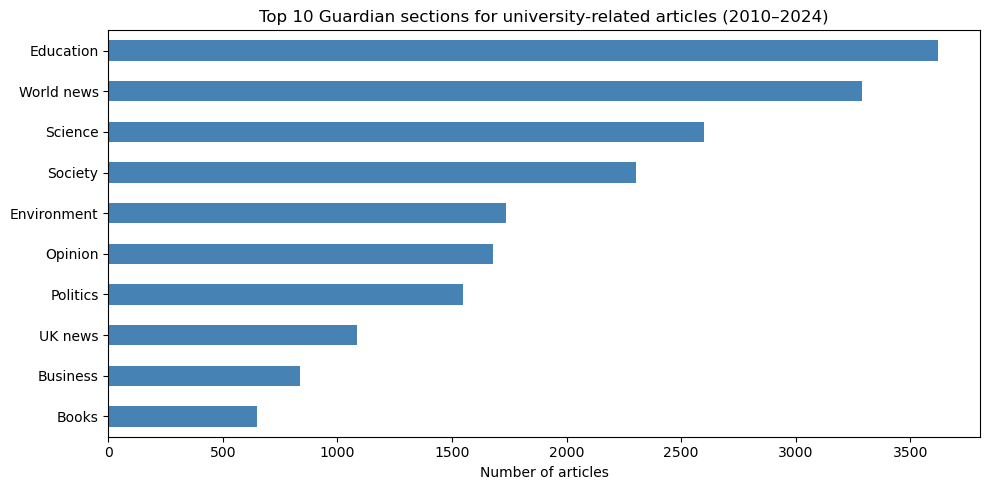

In [22]:
section_counts = clean_df["sectionName"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
section_counts.sort_values().plot(kind="barh", ax=ax, color="steelblue")

ax.set_title("Top 10 Guardian sections for university-related articles (2010–2024)", fontsize=12)
ax.set_xlabel("Number of articles")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### Interpretation

The distribution shows that articles are concentrated in a small number of sections, particularly education, world news, and science.\
This indicates that university-related topics appear across multiple sections rather than being confined to a single category.

## 5. Articles over time

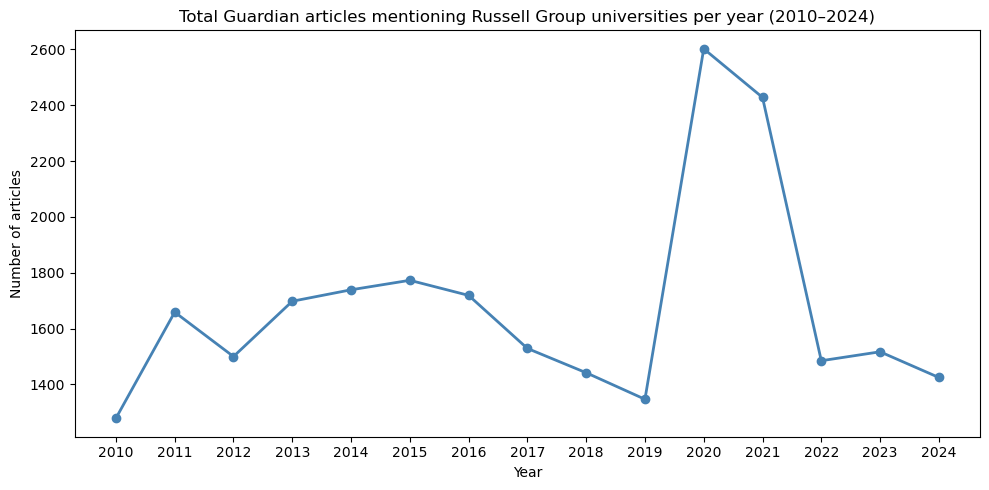

In [23]:
yearly_counts = clean_df.groupby("year").size()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_counts.index, yearly_counts.values, marker='o', color="steelblue", linewidth=2)

ax.set_title("Total Guardian articles mentioning Russell Group universities per year (2010–2024)", fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Number of articles")
ax.set_xticks(yearly_counts.index)

plt.tight_layout()
plt.show()

### Interpretation

The number of articles fluctuates over time rather than showing a consistent increasing or decreasing trend.\
A noticeable increase appears around 2020–2021, suggesting a period of higher media attention to universities.\
This pattern may be related to major real-world events during that period, although event-level data is not explicitly incorporated in this analysis.

## 6. Save cleaned dataset

In [36]:
clean_df.to_csv("data/final_dataset.csv", index=False)

## Summary

In this notebook, the dataset was prepared and examined through initial data analysis (IDA).

Key findings from IDA:
- 5,411 rows (21.5%) share an article ID across multiple universities due to cross-search overlap. These are retained for per-university analysis.
- 60 articles have wordcount = 0, corresponding to video content.
- All 10 universities have coverage in every year from 2010 to 2024, with no gaps.

Data cleaning converted date strings to datetime, created year, month, and year_month variables, and validated wordcount values. No rows were dropped. The cleaned dataset is saved to data/final_dataset.csv for use in subsequent analysis.